In [1]:
%load_ext autoreload
%autoreload 2

import data_formater as df
import calib as calib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

c:\GAMS\51\GMSPython\Lib\site-packages\dreamtools\gams_pandas\gdx.py:22: UserWarning: The GAMS version (51.4.0) differs from the API version (51.3.0).
  workspace = gams.GamsWorkspace()
c:\GAMS\51\GMSPython\Lib\site-packages\gams\core\numpy\gams2numpy.py:70: UserWarning: The GAMS version (51.4.0) differs from the API version (51.3.0).
  ws = GamsWorkspace(system_directory=system_directory)
c:\GAMS\51\GMSPython\Lib\site-packages\dreamtools\gams_pandas\gdx.py:22: UserWarning: The GAMS version (51.4.0) differs from the API version (51.3.0).
  workspace = gams.GamsWorkspace()
c:\GAMS\51\GMSPython\Lib\site-packages\gams\core\numpy\gams2numpy.py:70: UserWarning: The GAMS version (51.4.0) differs from the API version (51.3.0).
  ws = GamsWorkspace(system_directory=system_directory)


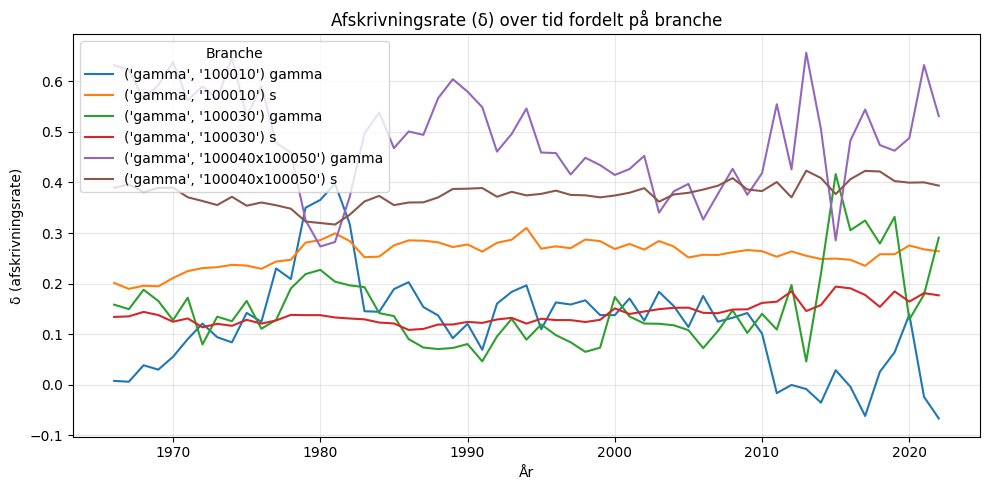

In [2]:
d = df.gamma.copy()
s = df.s.copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()
s_wide = s.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=f"{branche} gamma")
    plt.plot(s_wide.index, s_wide[branche], label=f"{branche} s")

plt.xlabel("År")
plt.ylabel("δ (afskrivningsrate)")
plt.title("Afskrivningsrate (δ) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


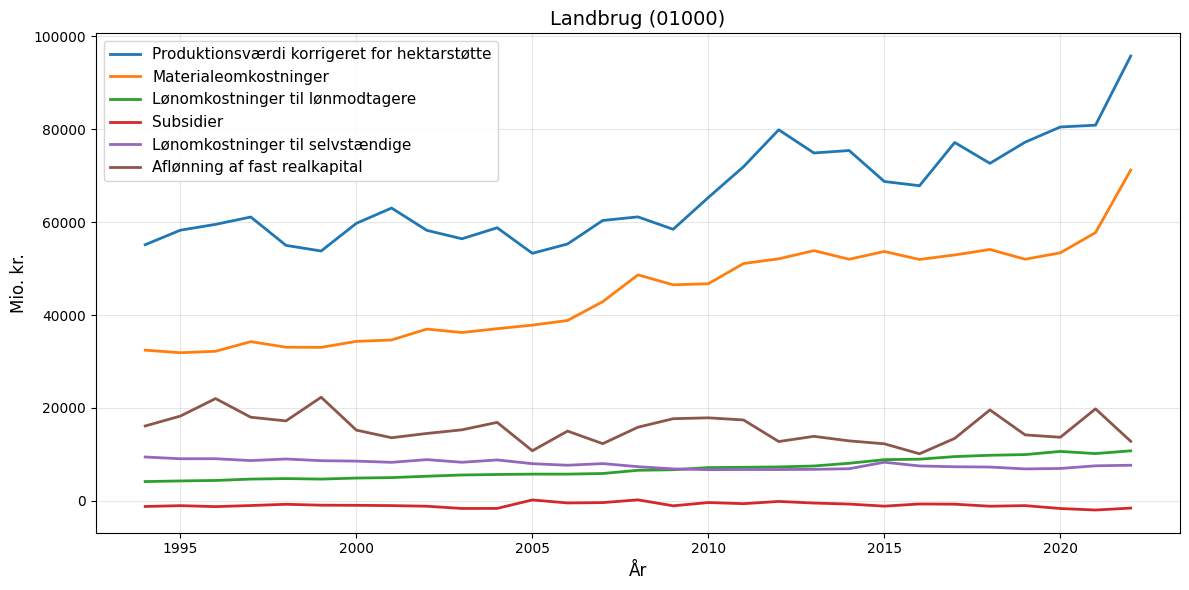

In [3]:
Produktionsværdi = df.P['Pt'].loc['010000', :] * df.Y['Xt'].loc['010000', :] 
Materialer =  calib.P_MxM_tot.loc['010000', :]
Lon_til_lonmodtager = df.w['Pt'].loc['010000', :] * df.L_lon['Xt'].loc['010000', :]
Subsidier= calib.subs_adj.loc['010000',:]
L_selv=df.w['Pt'].loc['010000', :] *(df.L['Xt'].loc['010000', :] - df.L_lon['Xt'].loc['010000', :])
K=calib.P_K.loc['010000', :] * calib.K_prev.loc['010000', :]

Produktionsværdi_filtered = Produktionsværdi.loc[Produktionsværdi.index >= 1994]
Materialer_filtered = Materialer.loc[Materialer.index >= 1994]
Lon_til_lonmodtager_filtered = Lon_til_lonmodtager.loc[Lon_til_lonmodtager.index >= 1994]
Subsidier_filtered = Subsidier.loc[Subsidier.index >= 1994]
L_selv_filtered = L_selv.loc[L_selv.index >= 1994]
K_filtered = K.loc[K.index >= 1994]

plt.figure(figsize=(12, 6))
plt.plot(Produktionsværdi_filtered.index, Produktionsværdi_filtered.values, label='Produktionsværdi korrigeret for hektarstøtte', linewidth=2)
plt.plot(Materialer_filtered.index, Materialer_filtered.values, label='Materialeomkostninger', linewidth=2)
plt.plot(Lon_til_lonmodtager_filtered.index, Lon_til_lonmodtager_filtered.values, label='Lønomkostninger til lønmodtagere', linewidth=2)
plt.plot(Subsidier_filtered.index, Subsidier_filtered.values, label='Subsidier', linewidth=2)
plt.plot(L_selv_filtered.index, L_selv_filtered.values, label='Lønomkostninger til selvstændige', linewidth=2)
plt.plot(K_filtered.index, K_filtered.values, label='Aflønning af fast realkapital', linewidth=2)

plt.xlabel('År', fontsize=12)
plt.ylabel('Mio. kr.', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# 1) Variabler du vil udtrække
variables_to_export = [
    "Y", "Mtot", "KL", "JKL", "K", "L", "J",
    "P", "w", "P_K", "P_KL", "P_JKL", "P_O",
    "mu_Y_Mtot", "mu_Y_KL", "mu_Y_JKL",
    "mu_JKL_J", "mu_JKL_KL",
    "mu_KL_K", "mu_KL_L",
    "markup", "tau_Y",
    "theta_Y_Mtot", "theta_Y_KL", "theta_Y_JKL",
    "theta_KL_K", "theta_KL_L",
    "theta_Mtot_M", "theta_MD", "theta_MF",
    "theta_JKL_J", "theta_JKL_KL",
]

# 2) Eksisterende Excel-fil (i samme mappe som notebook/script)
output_excel = "Dokumentation_ny.xlsx"

def get_var(var_name):
    # Finder variablen i df eller calib
    if hasattr(df, var_name):
        return getattr(df, var_name)
    if hasattr(calib, var_name):
        return getattr(calib, var_name)
    raise KeyError(f"Variabel '{var_name}' findes ikke i df eller calib")


def to_series(obj):
    if isinstance(obj, pd.Series):
        return obj
    if isinstance(obj, pd.DataFrame):
        for col in ["Xt", "Pt", "INDHOLD"]:
            if col in obj.columns:
                return obj[col]
        if len(obj.columns) == 1:
            return obj.iloc[:, 0]
        raise ValueError(
            f"DataFrame for variablen har flere kolonner ({list(obj.columns)}). "
            "Vælg én kolonne manuelt."
        )
    raise TypeError(f"Ukendt datatype: {type(obj)}")


def pivot_years(s):
    # Case 1: MultiIndex with TID
    if isinstance(s.index, pd.MultiIndex):
        if "TID" not in s.index.names:
            raise ValueError("Mangler 'TID' i MultiIndex")
        wide = s.unstack("TID")

    # Case 2: Single index that is TID
    else:
        if s.index.name != "TID":
            raise ValueError("Indeks er ikke 'TID'")
        wide = pd.DataFrame([s.values], columns=s.index)

    # Sort year columns
    try:
        wide = wide.reindex(sorted(wide.columns, key=lambda x: int(str(x))), axis=1)
    except Exception:
        wide = wide.sort_index(axis=1)

    return wide


def sort_key(x):
    s = str(x).strip()
    if s.isdigit():
        return (0, int(s))   # numeric-like first
    return (1, s)            # text after

def find_branch_level(index_names):
    candidates = ["BRANCHE", "ANVENDELSE", "branche", "anvendelse", "ERHVERV", "SEKTOR"]
    for c in candidates:
        if c in index_names:
            return c
    return None

def get_branches(var_names):
    branches = set()
    branch_level = None

    for var in var_names:
        s = to_series(get_var(var))
        if not isinstance(s.index, pd.MultiIndex):
            continue

        level = find_branch_level(s.index.names)
        if level is None:
            continue

        if branch_level is None:
            branch_level = level

        branches.update(s.index.get_level_values(level).unique().tolist())

    if not branches or branch_level is None:
        raise ValueError("Ingen branche-dimension fundet (fx BRANCHE/ANVENDELSE)")

    return sorted(branches, key=sort_key), branch_level


# 3) Skriv til eksisterende Excel-fil, ét ark pr. BRANCHE
with pd.ExcelWriter(output_excel, engine="openpyxl", mode="w") as writer:
    branches, branch_level = get_branches(variables_to_export)

    for branche in branches:
        var_tables = []

        for var in variables_to_export:
            s = to_series(get_var(var))

            if not isinstance(s.index, pd.MultiIndex) or branch_level not in s.index.names:
                continue

            # 🔥 vigtig ændring her
            if branche not in s.index.get_level_values(branch_level):
                continue

            s_branche = s.xs(branche, level=branch_level, drop_level=False)

            out = pivot_years(s_branche)

            out.columns = pd.MultiIndex.from_product(
                [[var], out.columns], names=["Variabel", "TID"]
            )

            var_tables.append(out)

        if not var_tables:
            print(f"Springer over BRANCHE {branche}: ingen data")
            continue

        branch_out = pd.concat(var_tables, axis=1)

        sheet = str(branche)[:31]
        branch_out.to_excel(writer, sheet_name=sheet)

        print(f"Eksporteret BRANCHE: {branche} -> {sheet}")

Eksporteret BRANCHE: 010000 -> 010000
Eksporteret BRANCHE: 100010 -> 100010
Eksporteret BRANCHE: 100030 -> 100030
Eksporteret BRANCHE: 100040x100050 -> 100040x100050
Eksporteret BRANCHE: REST -> REST


In [5]:
for v in variables_to_export[:8]:
    s = to_series(get_var(v))
    print(v, type(s.index), getattr(s.index, "names", None))

Y <class 'pandas.core.indexes.multi.MultiIndex'> ['ANVENDELSE', 'TID']
Mtot <class 'pandas.core.indexes.multi.MultiIndex'> ['ANVENDELSE', 'TID']
KL <class 'pandas.core.indexes.multi.MultiIndex'> ['ANVENDELSE', 'TID']
JKL <class 'pandas.core.indexes.multi.MultiIndex'> ['ANVENDELSE', 'TID']
K <class 'pandas.core.indexes.multi.MultiIndex'> ['ANVENDELSE', 'TID']
L <class 'pandas.core.indexes.multi.MultiIndex'> ['ANVENDELSE', 'TID']
J <class 'pandas.core.indexes.multi.MultiIndex'> ['ANVENDELSE', 'TID']
P <class 'pandas.core.indexes.multi.MultiIndex'> ['ANVENDELSE', 'TID']


In [6]:
# 1) Variabler du vil udtrække
variables_to_export = [
    "Y", "Mtot", "KL", "JKL", "K", "L", "J", "I",
    "P", "w", "P_K", "P_KL", "P_JKL", "P_O",
    "P_Mtot", "P_J", "P_Jord", "P_I",
    "mu_Y_Mtot", "mu_Y_KL", "mu_Y_JKL",
    "mu_JKL_J", "mu_JKL_KL",
    "mu_KL_K", "mu_KL_L",
    "markup", "tau_Y", "tau_MD", "tau_MF",
    "theta_Y_Mtot", "theta_Y_KL", "theta_Y_JKL",
    "theta_KL_K", "theta_KL_L",
    "theta_Mtot_M", "theta_MD", "theta_MF",
    "theta_JKL_J", "theta_JKL_KL",
]

# 2) Eksisterende Excel-fil (i samme mappe som notebook/script)
output_excel = "Dokumentation.xlsx"

def get_var(var_name):
    # Finder variablen i df eller calib
    if hasattr(df, var_name):
        return getattr(df, var_name)
    if hasattr(calib, var_name):
        return getattr(calib, var_name)
    raise KeyError(f"Variabel '{var_name}' findes ikke i df eller calib")


def to_series(obj):
    if isinstance(obj, pd.Series):
        return obj
    if isinstance(obj, pd.DataFrame):
        for col in ["Xt", "Pt", "INDHOLD"]:
            if col in obj.columns:
                return obj[col]
        if len(obj.columns) == 1:
            return obj.iloc[:, 0]
        raise ValueError(
            f"DataFrame for variablen har flere kolonner ({list(obj.columns)}). "
            "Vælg én kolonne manuelt."
        )
    raise TypeError(f"Ukendt datatype: {type(obj)}")


def pivot_years(s):
    if isinstance(s.index, pd.MultiIndex):
        if "TID" not in s.index.names:
            raise ValueError("Mangler 'TID' i MultiIndex")
        wide = s.unstack("TID")
    else:
        if s.index.name != "TID":
            raise ValueError("Indeks er ikke 'TID'")
        wide = pd.DataFrame([s.values], columns=s.index)

    try:
        wide = wide.reindex(sorted(wide.columns, key=lambda x: int(str(x))), axis=1)
    except Exception:
        wide = wide.sort_index(axis=1)

    return wide


# 3) Skriv til eksisterende Excel-fil, ét ark pr. variabel
with pd.ExcelWriter(output_excel, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    for var in variables_to_export:
        raw = get_var(var)
        s = to_series(raw)
        out = pivot_years(s)

        # Excel-arknavn max 31 tegn
        sheet = var[:31]
        out.to_excel(writer, sheet_name=sheet)
        print(f"Eksporteret: {var} -> {sheet}")

Eksporteret: Y -> Y
Eksporteret: Mtot -> Mtot
Eksporteret: KL -> KL
Eksporteret: JKL -> JKL
Eksporteret: K -> K
Eksporteret: L -> L
Eksporteret: J -> J
Eksporteret: I -> I
Eksporteret: P -> P
Eksporteret: w -> w
Eksporteret: P_K -> P_K
Eksporteret: P_KL -> P_KL
Eksporteret: P_JKL -> P_JKL
Eksporteret: P_O -> P_O
Eksporteret: P_Mtot -> P_Mtot
Eksporteret: P_J -> P_J
Eksporteret: P_Jord -> P_Jord
Eksporteret: P_I -> P_I
Eksporteret: mu_Y_Mtot -> mu_Y_Mtot
Eksporteret: mu_Y_KL -> mu_Y_KL
Eksporteret: mu_Y_JKL -> mu_Y_JKL
Eksporteret: mu_JKL_J -> mu_JKL_J
Eksporteret: mu_JKL_KL -> mu_JKL_KL
Eksporteret: mu_KL_K -> mu_KL_K
Eksporteret: mu_KL_L -> mu_KL_L
Eksporteret: markup -> markup
Eksporteret: tau_Y -> tau_Y
Eksporteret: tau_MD -> tau_MD
Eksporteret: tau_MF -> tau_MF
Eksporteret: theta_Y_Mtot -> theta_Y_Mtot
Eksporteret: theta_Y_KL -> theta_Y_KL
Eksporteret: theta_Y_JKL -> theta_Y_JKL
Eksporteret: theta_KL_K -> theta_KL_K
Eksporteret: theta_KL_L -> theta_KL_L
Eksporteret: theta_Mtot_M ->

In [7]:
for v in variables_to_export:
    s = to_series(get_var(v))
    print(
        v,
        type(s.index).__name__,
        "name=", getattr(s.index, "name", None),
        "names=", getattr(s.index, "names", None),
    )

Y MultiIndex name= None names= ['ANVENDELSE', 'TID']
Mtot MultiIndex name= None names= ['ANVENDELSE', 'TID']
KL MultiIndex name= None names= ['ANVENDELSE', 'TID']
JKL MultiIndex name= None names= ['ANVENDELSE', 'TID']
K MultiIndex name= None names= ['ANVENDELSE', 'TID']
L MultiIndex name= None names= ['ANVENDELSE', 'TID']
J MultiIndex name= None names= ['ANVENDELSE', 'TID']
I MultiIndex name= None names= ['ANVENDELSE', 'TID']
P MultiIndex name= None names= ['ANVENDELSE', 'TID']
w MultiIndex name= None names= ['ANVENDELSE', 'TID']
P_K MultiIndex name= None names= ['ANVENDELSE', 'TID']
P_KL MultiIndex name= None names= ['ANVENDELSE', 'TID']
P_JKL MultiIndex name= None names= ['ANVENDELSE', 'TID']
P_O MultiIndex name= None names= ['ANVENDELSE', 'TID']
P_Mtot MultiIndex name= None names= ['ANVENDELSE', 'TID']
P_J Index name= TID names= ['TID']
P_Jord Index name= TID names= ['TID']
P_I MultiIndex name= None names= ['ANVENDELSE', 'TID']
mu_Y_Mtot MultiIndex name= None names= ['ANVENDELSE', '

In [8]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

brancher = calib.theta_Y_KL_indeks.index.get_level_values('ANVENDELSE').unique()
tilgang_labels = {'010000': 'Landbrugssektor', '100010': 'Slagterier', '100030': 'Mejerier', '100040x100050': 'Anden fødevareindustri', 'REST': 'Resten af økonomien'}

pdf_filename = "produktivitetsparametre_alle_brancher.pdf"

with PdfPages(pdf_filename) as pdf:
    for branche in brancher:

        # --- Figur 1: Y-niveau ---
        d = calib.theta_Y_KL_indeks.loc[branche, slice(1994, 2022)]
        p = calib.theta_Y_Mtot_indeks.loc[branche, slice(1994, 2022)]
        years = d.index.get_level_values('TID')

        plt.figure(figsize=(10,5))
        plt.plot(years, d.values, label=r'$\theta^{Y,KL}_{it}$  (Kapital + Arbejde)')
        plt.plot(years, p.values, label=r'$\theta^{Y,M}_{it}$  (Materialer)')
        plt.xlabel("År")
        plt.ylabel("Indeks (1994=1)")
        plt.title(f"Produktivitetsparametre – Branche {branche}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(bottom=0)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

        # --- Figur 2: KL-niveau ---
        d = calib.theta_KL_K_indeks.loc[branche, slice(1994, 2022)]
        p = calib.theta_KL_L_indeks.loc[branche, slice(1994, 2022)]
        years = d.index.get_level_values('TID')

        plt.figure(figsize=(10,5))
        plt.plot(years, d.values, label=r'$\theta^{KL,K}_{it}$  (Kapital)')
        plt.plot(years, p.values, label=r'$\theta^{KL,L}_{it}$  (Arbejde)')
        plt.xlabel("År")
        plt.ylabel("Indeks (1994=1)")
        plt.title(f"KL-produktivitetsparametre – Branche {branche}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(bottom=0)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

        # --- Figur 3: Mtot-M niveau ---
        d = calib.theta_Mtot_M_indeks.loc[(branche, slice(None), slice(1994, 2022))]
        d_wide = d.unstack('TILGANG2').sort_index()
        years = d_wide.index.get_level_values('TID')

        plt.figure(figsize=(10,5))
        for col in d_wide.columns:
            plt.plot(years, d_wide[col], label=col)
        plt.xlabel("År")
        plt.ylabel("Indeks (1994=1)")
        plt.title(rf'$\theta^{{Mtot,M}}_{{it}}$ Materiale-CES – Branche {branche}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(bottom=0)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

        # --- Figur 4-6: MD/MF per tilgang ---
        for tilgang, label in tilgang_labels.items():
            try:
                d = calib.theta_MD_indeks.loc[(branche, tilgang, slice(1994, 2022))]
                p = calib.theta_MF_indeks.loc[(branche, tilgang, slice(1994, 2022))]
                years = d.index.get_level_values('TID')

                plt.figure(figsize=(10,5))
                plt.plot(years, d.values, label=r'$\theta^{MD}_{it}$ Danske materialer')
                plt.plot(years, p.values, label=r'$\theta^{MF}_{it}$ Importerede materialer')
                plt.xlabel("År")
                plt.ylabel("Indeks (1994=1)")
                plt.title(f"Materiale-CES – {label} – Branche {branche}")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.ylim(bottom=0)
                plt.tight_layout()
                pdf.savefig()
                plt.close()
            except KeyError:
                plt.close()
                continue

        # --- Figur 7: JKL (kun landbrug) ---
        if branche == '010000':
            try:
                d = calib.theta_JKL_J_indeks.loc['010000', 1994:2022]
                p = calib.theta_JKL_KL_indeks.loc['010000', 1994:2022]
                years = d.index.get_level_values('TID')
                
                plt.figure(figsize=(10,5))
                plt.plot(years, d.values, label=r'$\theta^{JKL,J}_{it}$  (Jord)')
                plt.plot(years, p.values, label=r'$\theta^{JKL,KL}_{it}$  (KL-aggregat)')
                plt.xlabel("År")
                plt.ylabel("Indeks (1994=1)")
                plt.title("JKL-produktivitetsparametre – Landbrug (01000)")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.ylim(bottom=0)
                plt.tight_layout()
                pdf.savefig()
                plt.close()
            except KeyError:
                plt.close()

print(f"Alle figurer er gemt i {pdf_filename}")

Alle figurer er gemt i produktivitetsparametre_alle_brancher.pdf


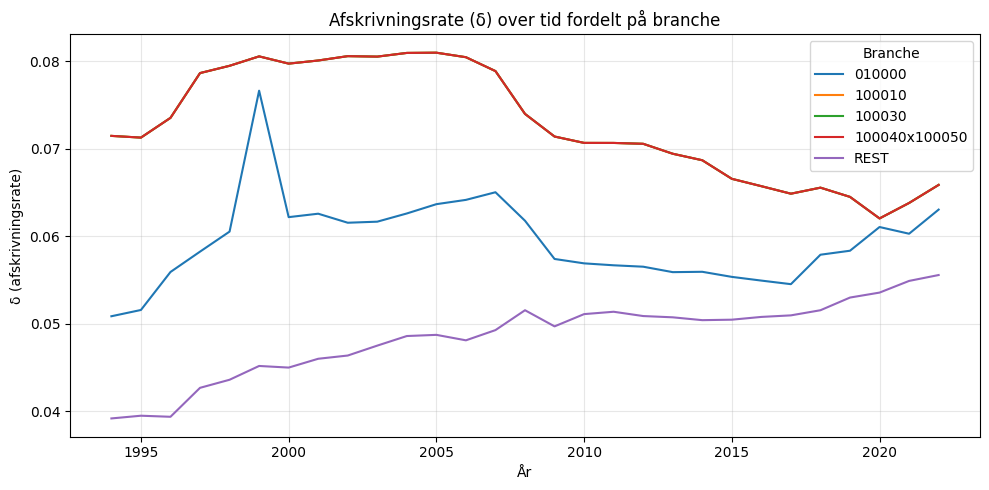

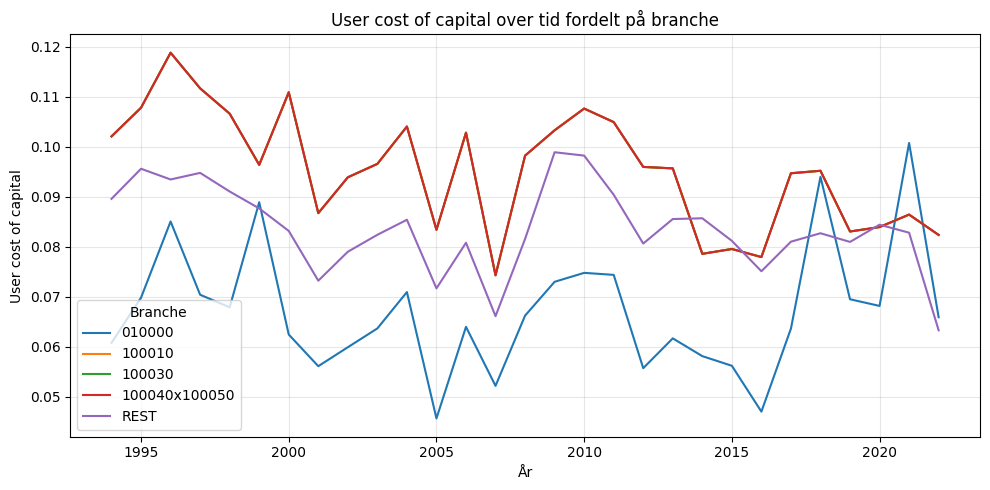

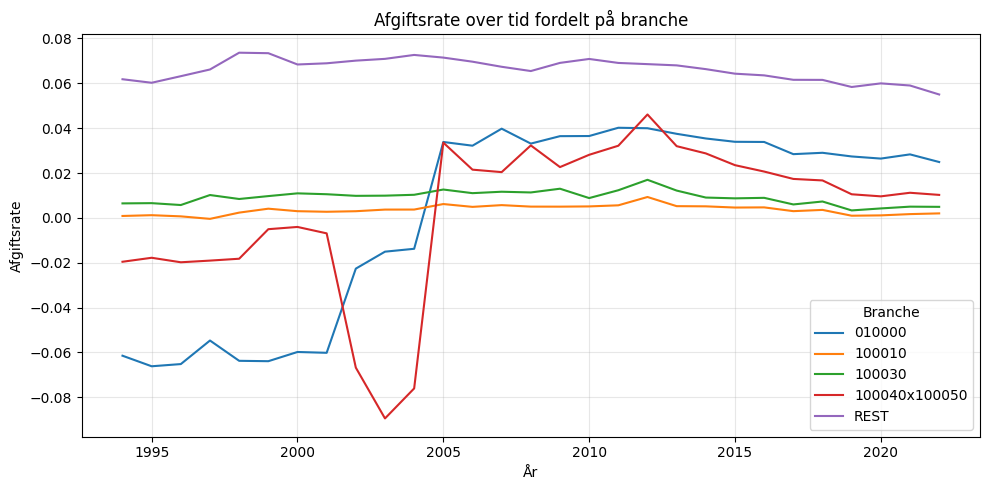

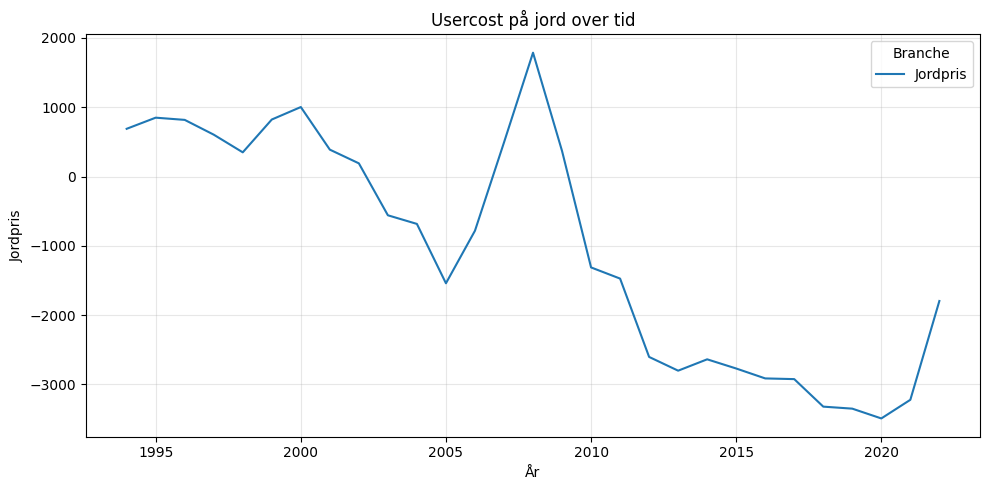

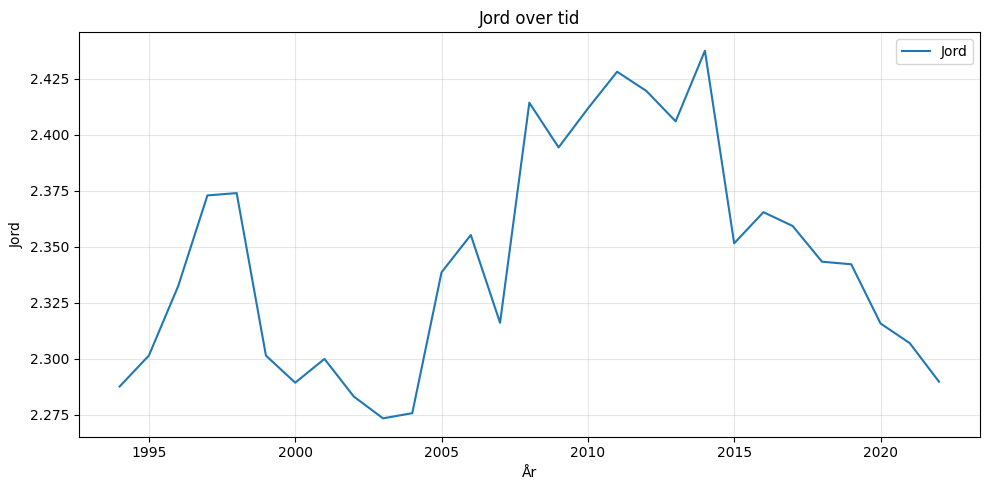

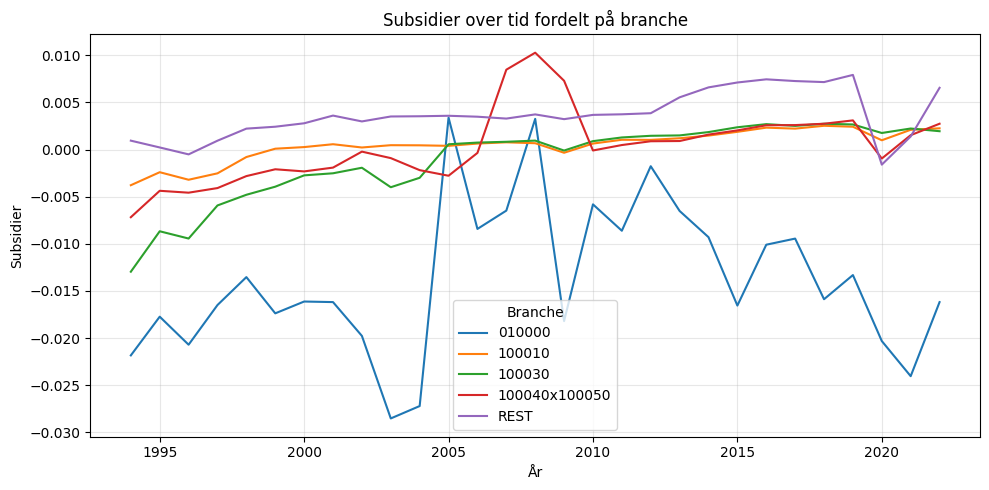

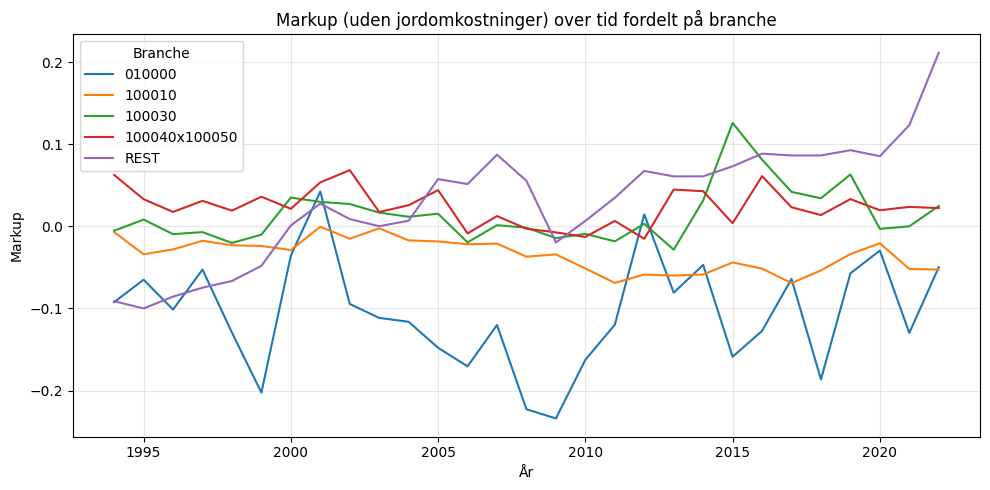

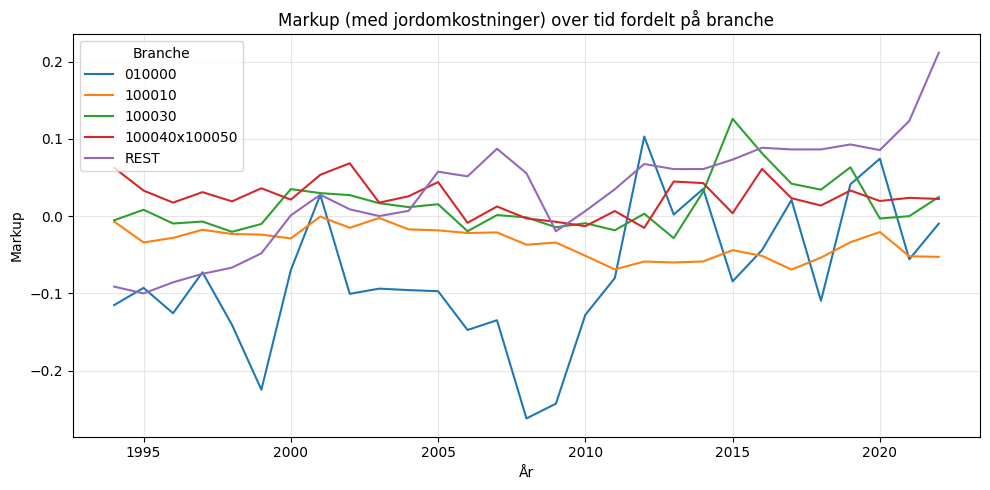

In [9]:

# Kun 1993 og frem
d = calib.delta.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("δ (afskrivningsrate)")
plt.title("Afskrivningsrate (δ) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

calib.P_K = calib.P_K.to_frame(name='Pt')
# Kun 1993 og frem
d = calib.P_K['Pt'].loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("User cost of capital")
plt.title("User cost of capital over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.tau_MD.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Afgiftsrate")
plt.title("Afgiftsrate over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.P_J.loc[(slice(1994, 2022))].copy()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(d.index, d, label='Jordpris')

plt.xlabel("År")
plt.ylabel("Jordpris")
plt.title("Usercost på jord over tid")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
# Få data
d = df.J['Xt'].loc['010000', slice(1994, 2022)].copy()

# Plot
plt.figure(figsize=(10, 5))
# Udtræk tidsdimensionen fra MultiIndex
years = d.index.get_level_values('TID') if 'TID' in d.index.names else d.index
plt.plot(years, d.values, label='Jord')
plt.xlabel("År")
plt.ylabel("Jord")
plt.title("Jord over tid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Kun 1993 og frem
d = calib.tau_Y.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Subsidier")
plt.title("Subsidier over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = (calib.P_MxM_tot + calib.P_KLxKL) / df.Y['Xt']
markup=df.P['Pt']/((1+calib.tau_Y)*d)-1

# Gør den "wide": år som index, branche som kolonner
d_wide = markup.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Markup")
plt.title("Markup (uden jordomkostninger) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.markup.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Markup")
plt.title("Markup (med jordomkostninger) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()